##### Task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes

In [45]:
### Import all necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

### Tasks:
##### 1. Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR


In [46]:
### Load the data set
df=pd.read_csv('ToyotaCorolla - MLR.csv')

In [47]:
### Size of data
df.shape

(1436, 11)

In [48]:
# Information of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [49]:
# first 5 rows of  data
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [50]:
### Statistics Summary
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [51]:
### Check duplicates
df.duplicated().sum()

np.int64(1)

In [52]:
# 1 Duplicate is found, drop the du[licate
df.drop_duplicates(inplace=True,ignore_index=True)

In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
### Check Missing values
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [55]:
### Check Unique Values in Categorical Columns
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    1264
Diesel     154
CNG         17
Name: count, dtype: int64

In [56]:
df['Automatic'].value_counts()

Automatic
0    1355
1      80
Name: count, dtype: int64

In [57]:
df['Doors'].value_counts()

Doors
5    673
3    622
4    138
2      2
Name: count, dtype: int64

In [58]:
df['Cylinders'].value_counts()

Cylinders
4    1435
Name: count, dtype: int64

The Cylinders variable is a discrete numerical feature representing the number of engine cylinders. However, all observations have the same value (4 cylinders), resulting in zero variance. Hence, the variable was removed from further analysis as it does not contribute to price prediction.

In [59]:
df['Gears'].value_counts()

Gears
5    1389
6      43
3       2
4       1
Name: count, dtype: int64

The Gears variable is a discrete numerical feature representing the number of gears in the vehicle. However, all observations have the same value (5 gears), resulting in zero variance. Hence, the variable was removed from further analysis as it does not contribute to price prediction.

In [60]:
### Drop the constant columns (Cylinders,Gears) from  dataset
df.drop(columns=['Cylinders','Gears'], inplace=True)

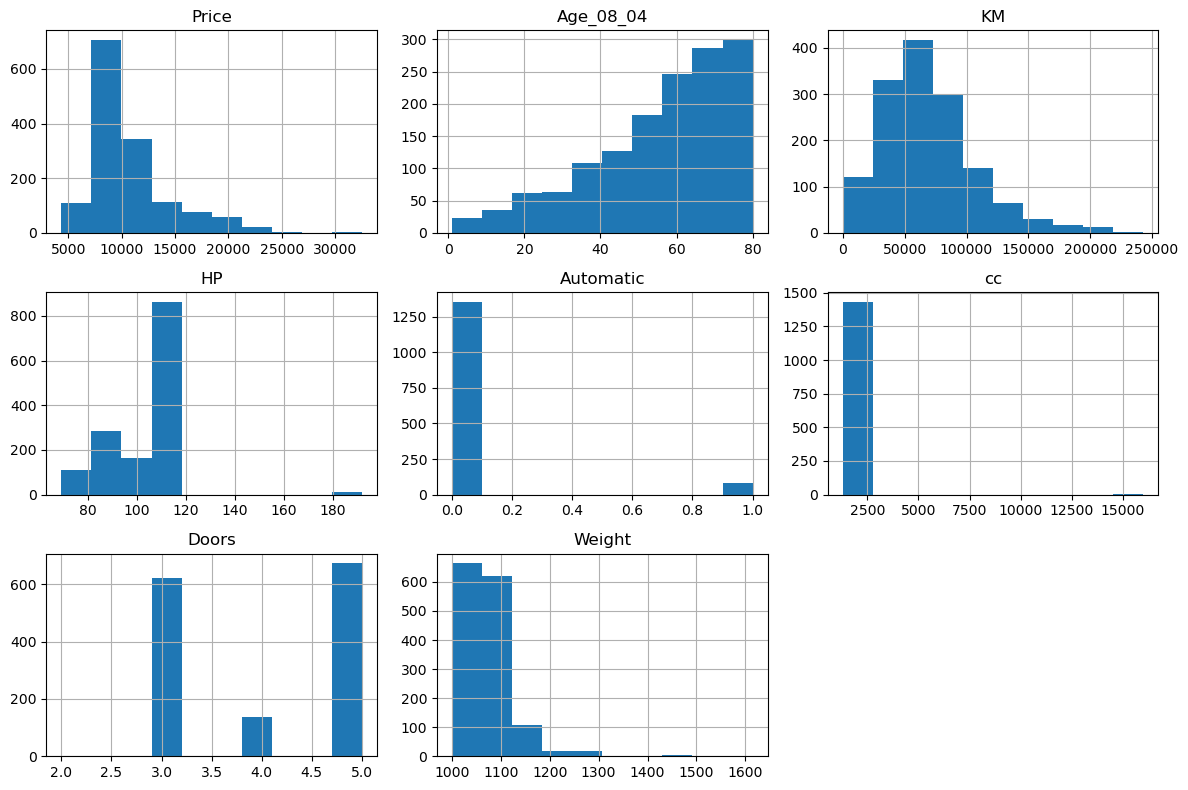

In [61]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

### Observation
The histograms show that most cars in the dataset have similar characteristics in terms of age, horsepower and weight. Most vehicles are manual transmission cars with either 3 or 5 doors. A few extreme values can be seen in variables such as Price, KM, and cc, indicating the presence of possible outliers. Overall, the dataset provides useful information for predicting car prices using Multiple Linear Regression.

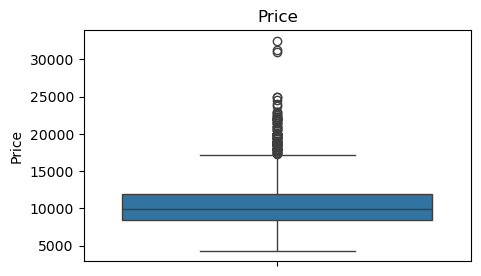

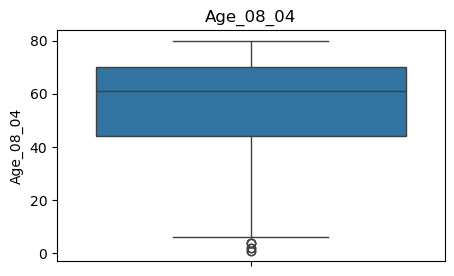

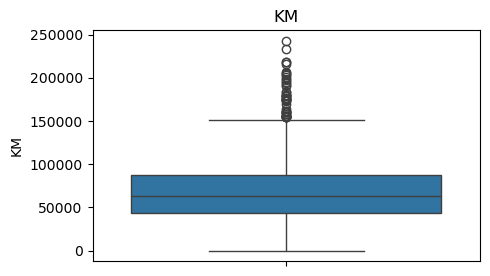

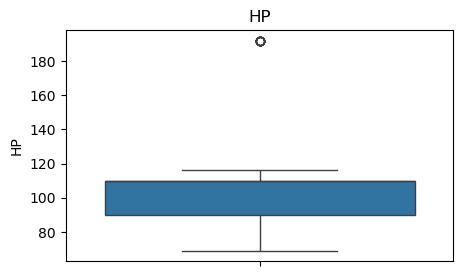

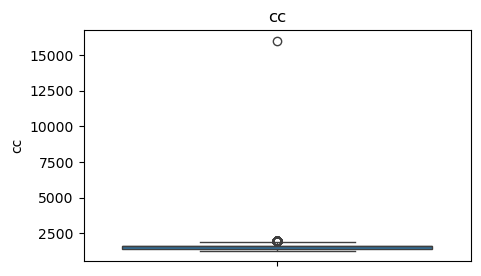

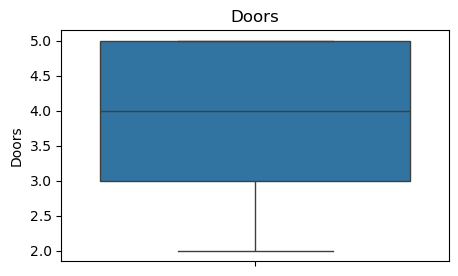

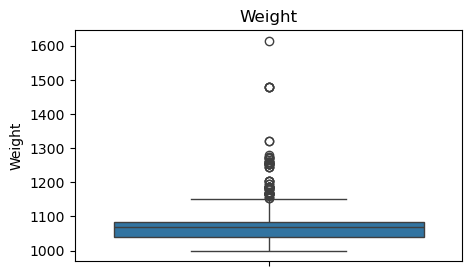

In [62]:
### Outlier check
num_cols = ['Price','Age_08_04','KM','HP',
            'cc','Doors','Weight']

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

In [63]:
### Outliers found, perform outlier capping
for col in num_cols :
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_extreme = Q1 - 1.5 * IQR
        upper_extreme = Q3 + 1.5 * IQR
        df[col] = df[col].apply(lambda x: lower_extreme if x < lower_extreme else upper_extreme if x > upper_extreme else x)

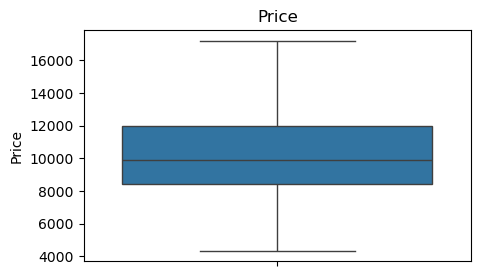

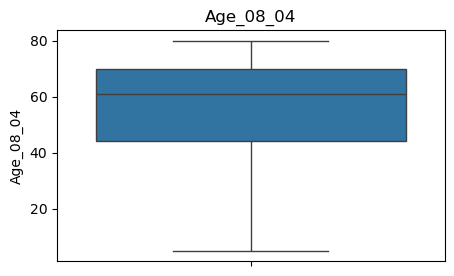

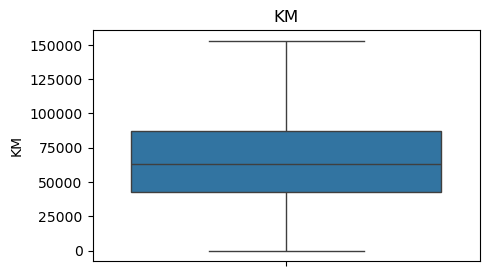

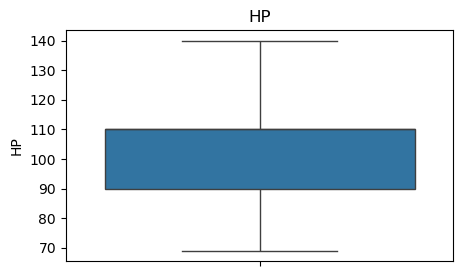

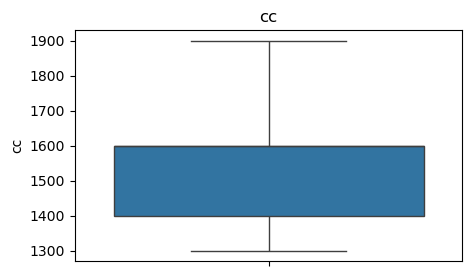

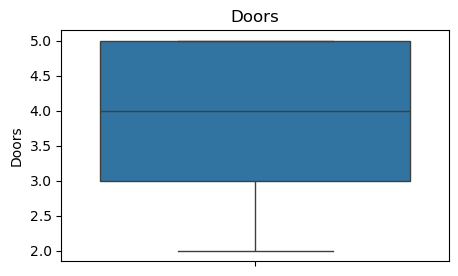

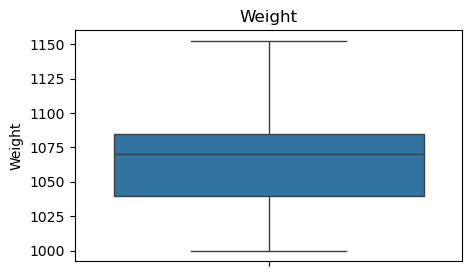

In [64]:
### Outlier check
num_cols = ['Price','Age_08_04','KM','HP',
            'cc','Doors','Weight']

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

In [65]:
### Encode Fuel_Type
temp_df = pd.get_dummies(df,
                         columns=['Fuel_Type'],
                         drop_first=True,
                         dtype=int)

The categorical variable Fuel_Type was converted into dummy variables using one-hot encoding.

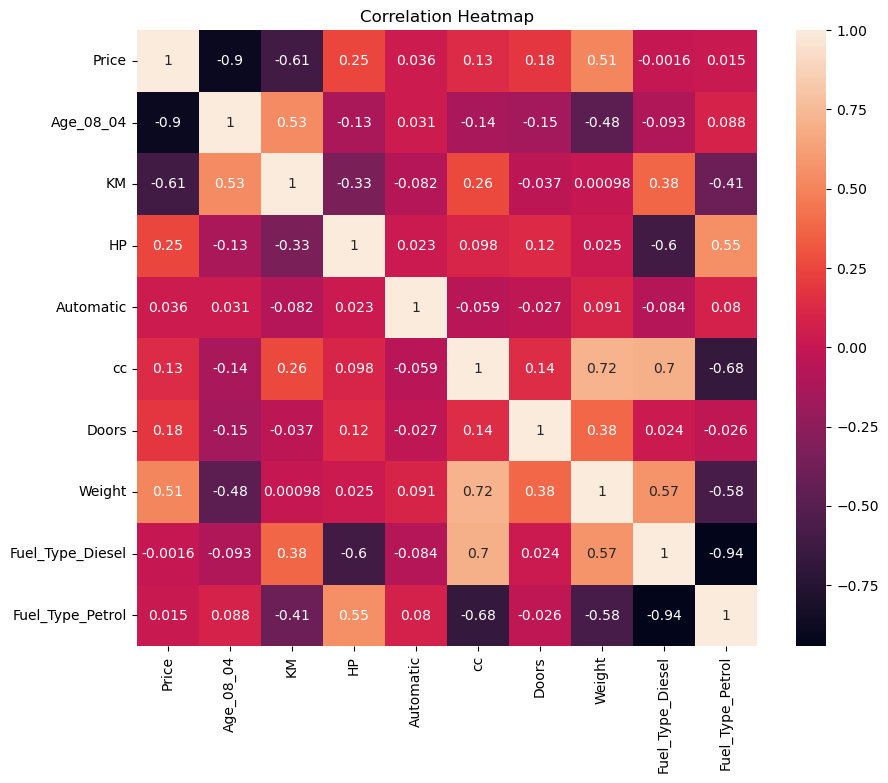

In [66]:
#### Correlation
plt.figure(figsize=(10,8))
sns.heatmap(temp_df.corr(),
            annot=True)
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that Age_08_04 has the strongest relationship with Price. As the age of the car increases, the price decreases. KM also has a negative relationship with Price, which means cars that have been driven more tend to have lower prices. Weight has a positive relationship with Price, indicating that heavier cars generally have higher prices. HP and Doors also show a positive relationship with Price, but their impact is smaller. Variables such as Automatic and Fuel_Type have very little effect on Price. Some variables are strongly related to each other, so further checks are needed before building the regression model.

In [67]:
target= temp_df[['Price']]
features= temp_df.drop(columns=['Price'])

In [68]:
features.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,23.0,46986.0,90.0,0,1900.0,3,1152.5,1,0
1,23.0,72937.0,90.0,0,1900.0,3,1152.5,1,0
2,24.0,41711.0,90.0,0,1900.0,3,1152.5,1,0
3,26.0,48000.0,90.0,0,1900.0,3,1152.5,1,0
4,30.0,38500.0,90.0,0,1900.0,3,1152.5,1,0


In [69]:
#### Variance Inflation Factor (VIF)--- To check Multicolinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif['features'] = features.columns
vif['VIF Scores'] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
vif

,features,VIF Scores
0,Age_08_04,17.536494
1,KM,9.755270
2,HP,608.303041
3,Automatic,1.099255
4,cc,1099.113107
5,Doors,21.376659
6,Weight,355.074785
7,Fuel_Type_Diesel,30.300075
8,Fuel_Type_Petrol,72.338494


##### 2. Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [70]:
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 9)
(287, 9)
(1148, 1)
(287, 1)


#### 3. Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [71]:
#### Model Training
base_model=LinearRegression()
base_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 9)","[[-105.55, -0.01, 27.2 ,..., 25.42,1036.48,1095.31]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Age_08_04','KM','HP',...,'Weight','Fuel_Type_Diesel','Fuel_Type_Petrol']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-9252.33]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


### Base model (Model 1)

In [72]:
#### Model Training and Validation
base_model=LinearRegression()
base_model.fit(x_train,y_train)

### Training Validation
y_pred=base_model.predict(x_train)
train_acc=r2_score(y_train,y_pred)

### Testing Validation
y_pred1=base_model.predict(x_test)
test_acc=r2_score(y_test,y_pred1)

print("Train Accuracy:", train_acc,',' "Test Accuracy:", test_acc)

Train Accuracy: 0.8691203234572424 ,Test Accuracy: 0.8505852051526696


The model performed well on both the training and testing datasets. The training accuracy was 86.91%, and the testing accuracy was 85.06%. The small difference between the two scores indicates that the model is stable and can predict car prices reasonably well on new data.

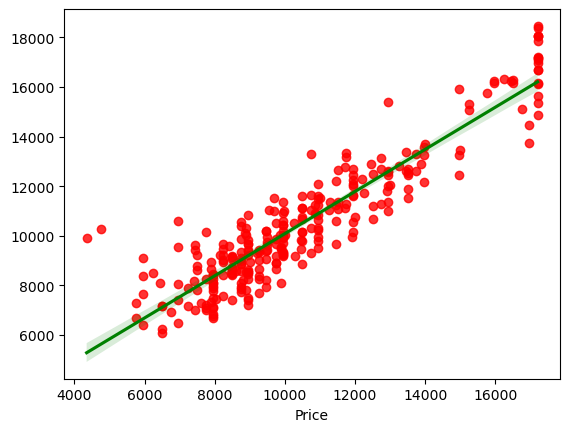

In [73]:
#### Regression Plot
sns.regplot(x=y_test,y=y_pred1,scatter_kws={'color':'red'},line_kws={'color':'green'})
plt.show()

#### 4. Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [74]:
#### Error Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error

In [75]:
### Mean Squared Error
mse=mean_squared_error(y_test,y_pred1)
mse

1266092.0656426623

In [76]:
#### Root Mean Squared Error
rmse= np.sqrt(mse)
rmse

np.float64(1125.2075655818628)

In [77]:
#### Mean Absolute Error
mae= mean_absolute_error(y_test,y_pred1)
mae

827.7654743470583

In [78]:
#### Mean Absolute Percentage Error
mape= mean_absolute_percentage_error(y_test,y_pred1)*100
mape

8.937665380118972

In [79]:
rsquared=r2_score(y_test,y_pred1)
rsquared

0.8505852051526696

In [80]:
x_test.shape

(287, 9)

In [81]:
k=9
N=287
adj_rsquared= 1-(((1-rsquared)*(N-1))/(N-k-1))
adj_rsquared

0.84573057282911

In [82]:
coef_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': base_model.coef_.flatten()
})

coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
8,Fuel_Type_Petrol,1095.308586
7,Fuel_Type_Diesel,1036.475211
3,Automatic,45.534285
2,HP,27.198490
6,Weight,25.417341
1,KM,-0.014862
4,cc,-2.541864
5,Doors,-89.337627
0,Age_08_04,-105.554122


#### Coefficient Interpretation
The model shows that Age_08_04 has the strongest negative impact on car price, while Fuel Type, Weight, and HP have a positive impact on price. Older cars generally have lower prices, whereas heavier cars and cars with higher horsepower tend to have higher prices.

### Model 2

In [83]:
### Dropping dropping the high-VIF variable cc the model is build

features_model2 = features.drop(columns=['cc'])

x_train2, x_test2, y_train2, y_test2 = train_test_split(features_model2,target,train_size=0.8,random_state=100)

#### Model Training and Validation
model2 = LinearRegression()
model2.fit(x_train2, y_train2)

### Training Validation
y_pred2 = model2.predict(x_train2)
train_acc2 = r2_score(y_train2, y_pred2)

### Testing Validation
y_pred2_test = model2.predict(x_test2)
test_acc2 = r2_score(y_test2, y_pred2_test)

print("Train Accuracy:", train_acc2, "," , "Test Accuracy:", test_acc2)

Train Accuracy: 0.8674621673380158 , Test Accuracy: 0.8493257430696957


After removing the cc variable, the model performance decreased only slightly. The training R² changed from 86.91% to 86.75%, and the testing R² changed from 85.06% to 84.93%. This indicates that the cc variable has a limited contribution to the prediction of car prices, and the model remains stable even after its removal.

In [84]:
mae2 = mean_absolute_error(y_test2, y_pred2_test)
mse2 = mean_squared_error(y_test2, y_pred2_test)
rmse2 = np.sqrt(mse2)

print("MAE:", mae2)
print("MSE:", mse2)
print("RMSE:", rmse2)

MAE: 833.0313830530595
MSE: 1276764.3350913497
RMSE: 1129.939969684828


After removing the cc variable, the model performance decreased. The R² score dropped to 84.93%, indicating that the model explains less variation in car prices compared to Model 1. The MAE and RMSE values increased, showing that the prediction errors became larger. This suggests that the removed variable contributes useful information to the model.

In [85]:
coef_model2 = pd.DataFrame({
    'Feature': x_train2.columns,
    'Coefficient': model2.coef_.flatten()
})

coef_model2.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
7,Fuel_Type_Petrol,1052.728019
3,Automatic,33.259992
5,Weight,24.010467
2,HP,1.997715
1,KM,-0.015756
4,Doors,-87.331752
0,Age_08_04,-107.499040
6,Fuel_Type_Diesel,-490.230099


#### Coefficient Interpretation
In Model 2, Age_08_04 remains the most important factor affecting car price negatively. Weight and Fuel_Type_Petrol have a positive influence on price. Compared to Model 1, the effect of HP became much smaller after removing the cc variable, indicating that these variables were related to each other.

#### Model 3

In [89]:
features_model3 = features[['Age_08_04', 'KM', 'HP', 'Weight']]

x_train3, x_test3, y_train3, y_test3 = train_test_split(features_model3,target,train_size=0.8,random_state=100)

model3 = LinearRegression()
model3.fit(x_train3, y_train3)

### Training Validation
y_pred3 = model3.predict(x_train3)
train_acc3 = r2_score(y_train3, y_pred3)

### Testing Validation
y_pred3_test = model3.predict(x_test3)
test_acc3 = r2_score(y_test3, y_pred3_test)

print("Train Accuracy:", train_acc3, "," , "Test Accuracy:", test_acc3)

Train Accuracy: 0.8607132830834222 , Test Accuracy: 0.8432298677684468


Model 3 performed well with a training accuracy of 86.07% and a testing accuracy of 84.32%. The training and testing scores are very close, which means the model is reliable. The model uses only four important features and still predicts car prices effectively.

In [90]:
mae3 = mean_absolute_error(y_test3, y_pred3_test)
mse3 = mean_squared_error(y_test3, y_pred3_test)
rmse3 = np.sqrt(mse3)

print("MAE:", mae3)
print("MSE:", mse3)
print("RMSE:", rmse3)
print("R2 Score:", test_acc3)

MAE: 855.8473586141636
MSE: 1328418.7871149553
RMSE: 1152.5705128602567
R2 Score: 0.8432298677684468


Model 3 performed well with an R² score of 84.32%. On average, the predicted price differs from the actual price by about 856 Euros. The RMSE of 1152.57 indicates a reasonable prediction error. Even with fewer features, the model was able to predict car prices effectively and achieved good accuracy.

In [91]:
coef_model3 = pd.DataFrame({
    'Feature': x_train3.columns,
    'Coefficient': model3.coef_.flatten()
})

coef_model3.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,HP,20.295333
3,Weight,15.301148
1,KM,-0.018787
0,Age_08_04,-108.201556


#### Coefficient Interpretation
Among the selected features, Age_08_04 has the strongest negative effect on car price, indicating that older cars generally have lower prices. HP and Weight have a positive impact on price, meaning that more powerful and heavier cars tend to be more expensive. KM also negatively affects price, showing that cars with higher mileage are usually sold at lower prices. Overall, these four variables are important factors in predicting the price of a Toyota Corolla.

#### 5.Apply Lasso and Ridge methods on the model.

#### Ridge

In [93]:
### Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [94]:
### Model Building
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [95]:
# Training Validation
y_pred_train_ridge = ridge_model.predict(X_train_scaled)
train_acc_ridge = r2_score(y_train, y_pred_train_ridge)

# Testing Validation
y_pred_test_ridge = ridge_model.predict(X_test_scaled)
test_acc_ridge = r2_score(y_test, y_pred_test_ridge)

print("Train Accuracy:", train_acc_ridge,
      ", Test Accuracy:", test_acc_ridge)

Train Accuracy: 0.8691185613456107 , Test Accuracy: 0.8505335198277536


In [96]:
### Error Metrics
mae_ridge = mean_absolute_error(y_test, y_pred_test_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_test_ridge)
rmse_ridge = np.sqrt(mse_ridge)

print("MAE:", mae_ridge)
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2 Score:", test_acc_ridge)

MAE: 827.9053549523592
MSE: 1266530.030168552
RMSE: 1125.402163747943
R2 Score: 0.8505335198277536


The Ridge Regression model achieved a training R² score of 86.91% and a testing R² score of 85.05%. The training and testing scores are very close, indicating that the model generalizes well to unseen data. The model achieved a MAE of 827.91 Euros and an RMSE of 1125.40 Euros, showing good prediction accuracy. Overall, Ridge Regression performed similarly to Multiple Linear Regression while helping to reduce the impact of multicollinearity among the predictor variables.

In [97]:
### Coefficients
ridge_coef = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': ridge_model.coef_.flatten()
})

ridge_coef

,Feature,Coefficient
0,Age_08_04,-1958.955864
1,KM,-515.239207
2,HP,351.628456
3,Automatic,10.172015
4,cc,-425.495642
5,Doors,-84.543057
6,Weight,975.029434
7,Fuel_Type_Diesel,306.449573
8,Fuel_Type_Petrol,351.386827


After standardization, the coefficients represent the relative importance of the variables. Age_08_04 has the strongest negative impact on price, indicating that older cars tend to have lower prices. Weight has the strongest positive impact, suggesting that heavier cars generally have higher prices. HP and fuel type also positively influence car prices. Ridge Regression shrinks the coefficient values and helps reduce the effect of multicollinearity while retaining all variables in the model.

Ridge Regression produced results very similar to Multiple Linear Regression. This indicates that the original model was already performing well, and Ridge Regression helped control multicollinearity without reducing prediction accuracy.

#### Lasso

In [98]:
### Model Building
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [99]:
# Training Validation
y_pred_train_lasso = lasso_model.predict(X_train_scaled)
train_acc_lasso = r2_score(y_train, y_pred_train_lasso)

# Testing Validation
y_pred_test_lasso = lasso_model.predict(X_test_scaled)
test_acc_lasso = r2_score(y_test, y_pred_test_lasso)

print("Train Accuracy:", train_acc_lasso,
      ", Test Accuracy:", test_acc_lasso)

Train Accuracy: 0.8691032280486124 , Test Accuracy: 0.8504688600158439


In [100]:
### Error Metrics
mae_lasso = mean_absolute_error(y_test, y_pred_test_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_test_lasso)
rmse_lasso = np.sqrt(mse_lasso)

print("MAE:", mae_lasso)
print("MSE:", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2 Score:", test_acc_lasso)

MAE: 828.0472176679854
MSE: 1267077.9362504669
RMSE: 1125.6455642210237
R2 Score: 0.8504688600158439


The Lasso Regression model achieved a training R² score of 86.91% and a testing R² score of 85.05%. The training and testing scores are very close, indicating that the model is stable and performs well on unseen data. The model achieved a MAE of 828.05 Euros and an RMSE of 1125.65 Euros, showing good prediction accuracy. Overall, Lasso Regression performed similarly to Multiple Linear Regression and Ridge Regression.

In [101]:
### Coefficients
lasso_coef = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': lasso_model.coef_
})

lasso_coef

,Feature,Coefficient
0,Age_08_04,-1962.924549
1,KM,-515.971302
2,HP,328.192791
3,Automatic,8.808215
4,cc,-398.765308
5,Doors,-83.551035
6,Weight,972.221824
7,Fuel_Type_Diesel,262.431313
8,Fuel_Type_Petrol,338.472135


Lasso Regression shrinks the coefficients and can remove less important features by making their coefficients close to zero. In this model, all variables still contribute to price prediction, although some have a smaller effect than others.

Three Multiple Linear Regression models, Ridge Regression, and Lasso Regression were developed to predict Toyota Corolla prices. Among the three MLR models, Model 1 achieved the best performance with an R² score of 85.06% and the lowest prediction errors. Ridge and Lasso Regression produced results very similar to Model 1, indicating that the model is robust even in the presence of multicollinearity. Important factors affecting price include Age_08_04, KM, HP, Weight, and Fuel Type. Overall, the models were able to predict Toyota Corolla prices with good accuracy.

### Interview Questions:

#### 1.What is Normalization & Standardization and how is it helpful?

**Normalization:**
Normalization changes the values of a dataset to a fixed range, usually between 0 and 1.

**Standardization:**
Standardization changes the data so that the mean becomes 0 and the standard deviation becomes 1.

**How is it helpful?**

* It brings all variables to a similar scale.
* It helps machine learning models perform better.
* It prevents variables with large values from having more influence than others.
* It is especially useful for Ridge and Lasso Regression.

#### 2.What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity occurs when independent variables are highly related to each other.

Some common ways to handle it are:

* Remove highly correlated variables.
* Use VIF (Variance Inflation Factor) to identify problematic variables.
* Apply Ridge Regression to reduce the effect of multicollinearity.
* Apply Lasso Regression to reduce or remove less important variables.
* Select only the most important features for the model.
* Use PCA (Principal Component Analysis) to create new independent variables.

In this project, VIF, Ridge Regression, and Lasso Regression were used to handle multicollinearity.